<h1>Breast Cancer Classification Algorithm Using Decision Tree</h1>

In [19]:
from matplotlib import pyplot as plt
from sklearn.datasets import load_breast_cancer
import pandas as pd
import seaborn as sns

In [2]:
breast_cancer_dataset = load_breast_cancer()
dataset = pd.DataFrame(breast_cancer_dataset.data, columns=breast_cancer_dataset.feature_names)

dataset.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [4]:
dataset.shape

(569, 30)

In [13]:
print("Columns Statistics:")
dataset.describe()

Columns Statistics:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [14]:
print("Column Data Types:")
dataset.dtypes

Column Data Types:


mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [9]:
is_missing_variable = dataset.isnull().values.any()
print(f"is_missing_variable = {is_missing_variable}")

is_missing_variable = False


/opt/anaconda3/envs/mlops-env/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/mlops-env/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


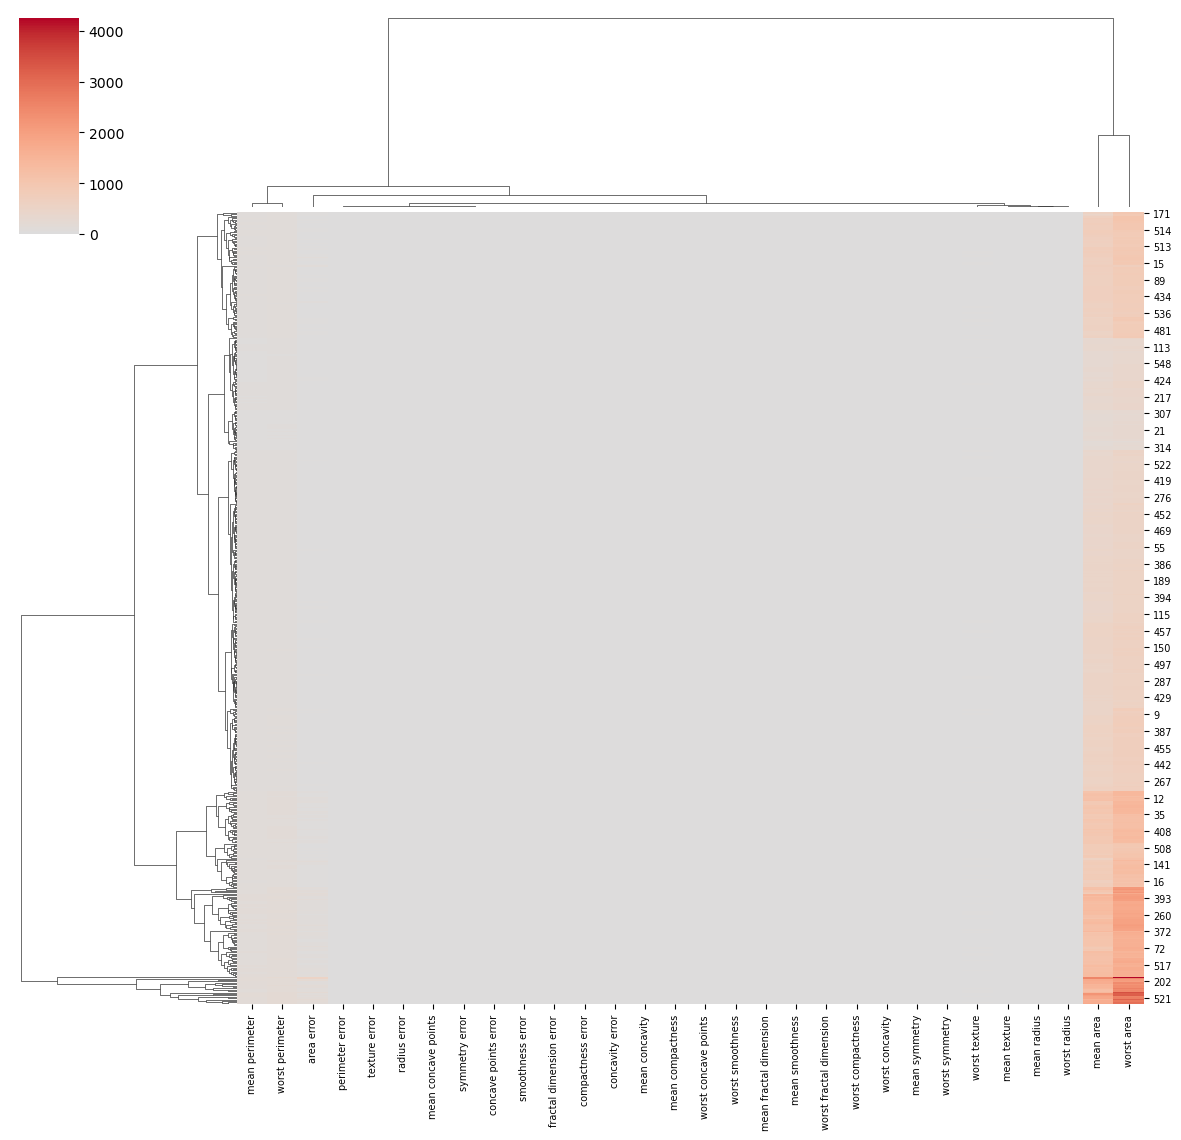

In [22]:
group = sns.clustermap(dataset, cmap="coolwarm", center=0, figsize = (12,12))
group.ax_heatmap.tick_params(labelsize=7)
plt.show()

In [25]:
print("Finding Correlation to Identify Feature Reduction:")
import numpy as np
corr = dataset.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack().sort_values(ascending=False)
)
high_corr_pairs[high_corr_pairs > 0.9]

Finding Correlation to Identify Feature Reduction:


mean radius          mean perimeter          0.997855
worst radius         worst perimeter         0.993708
mean radius          mean area               0.987357
mean perimeter       mean area               0.986507
worst radius         worst area              0.984015
worst perimeter      worst area              0.977578
radius error         perimeter error         0.972794
mean perimeter       worst perimeter         0.970387
mean radius          worst radius            0.969539
mean perimeter       worst radius            0.969476
mean radius          worst perimeter         0.965137
mean area            worst radius            0.962746
                     worst area              0.959213
                     worst perimeter         0.959120
radius error         area error              0.951830
mean perimeter       worst area              0.941550
mean radius          worst area              0.941082
perimeter error      area error              0.937655
mean concavity       mean co

<h1>Using DecisionTreeClassifier</h1>

In [31]:
X,y = breast_cancer_dataset.data, breast_cancer_dataset.target

class_names = breast_cancer_dataset.target_names

print(f"outputs: ${class_names}")

['malignant' 'benign']


In [73]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree_iris = DecisionTreeClassifier(random_state=0, criterion="entropy", class_weight="balanced", max_depth=3)
tree_iris.fit(X_train, y_train)
tree_iris = tree_iris.fit(X_train, y_train)

In [74]:
predicted = tree_iris.predict(X_test)

In [75]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(f"Accuracy: {accuracy_score(y_test, predicted)}")
print(f"Classification Report:")
print(classification_report(y_test, predicted, target_names=class_names))
print(confusion_matrix(y_test, predicted))
print(f"Confusion Matrix:")
print(confusion_matrix(y_test, predicted))

Accuracy: 0.956140350877193
Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

[[39  4]
 [ 1 70]]
Confusion Matrix:
[[39  4]
 [ 1 70]]


In [69]:
print("Train accuracy:", tree_iris.score(X_train, y_train))
print("Test accuracy:", tree_iris.score(X_test, y_test))

Train accuracy: 1.0
Test accuracy: 0.9385964912280702


Running results:<br/>
Tree Depth = 3<br/>
Train accuracy: 0.9802197802197802<br/>
Test accuracy: 0.956140350877193<br/>
Malignant Recall = 0.91<br/>
Benign Recall = 0.99<br/>
<br/>
Tree Depth = 5<br/>
Train accuracy: 0.9934065934065934<br/>
Test accuracy: 0.956140350877193<br/>
Malignant Recall = 0.91<br/>
Benign Recall = 0.99<br/>

Tree Depth = Default<br/>
Train accuracy: 1.0<br/>
Test accuracy: 0.9385964912280702<br/>
Malignant Recall = 0.88<br/>
Benign Recall = 0.92<br/>
<br/>
Best Configuration: max_depth=3

<h1>GridSearchCV</h1>
Helps find best params for a given dataset without manual param changes

In [110]:
from sklearn.model_selection import GridSearchCV

params_grid = {
    "max_depth": [2,3,4,5,6,7,None],
    "criterion": ["gini", "entropy"],
    "min_samples_split": [2, 3, 4, 5,6, 7, 10],
    "min_samples_leaf": [1, 2, 3, 4, 5]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=0), params_grid, cv=3, scoring="recall", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)
print("Best Score:")
print(grid.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 2}
Best Score:
0.9649488304093566


<h1>Learning Curve</h1>

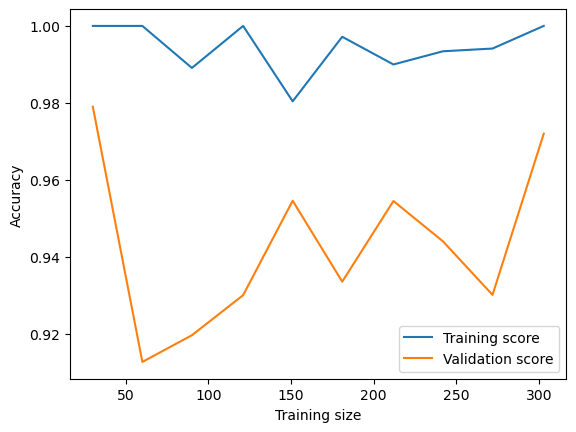

In [119]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    DecisionTreeClassifier(random_state=0, criterion="entropy", class_weight="balanced", max_depth=4, min_samples_split=2, min_samples_leaf=1),
    X_train, y_train,
    cv=3,
    scoring="recall",
    train_sizes=np.linspace(.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, val_mean, label="Validation score")
plt.legend()
plt.xlabel("Training size")
plt.ylabel("Accuracy")
plt.show()

In [107]:
val_mean[-3:]

array([0.9439693 , 0.93004386, 0.97196637])

In [108]:
train_mean[-3:]

array([0.99340653, 0.99411765, 1.        ])

<h2>Checking Learning Models<h2>

In [115]:
results = pd.DataFrame(grid.cv_results_)
results.sort_values("mean_test_score", ascending=False).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
364,0.002922,0.000222,0.000769,0.000008,entropy,5,3,2,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.989583,0.926316,0.978947,0.964949,0.027661,1
294,0.002541,0.000035,0.000782,0.000041,entropy,3,3,2,"{'criterion': 'entropy', 'max_depth': 3, 'min_...",0.989583,0.936842,0.968421,0.964949,0.021671,1
369,0.003446,0.000763,0.002032,0.001698,entropy,5,3,7,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.989583,0.926316,0.978947,0.964949,0.027661,1
368,0.004496,0.002357,0.000838,0.000102,entropy,5,3,6,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.989583,0.926316,0.978947,0.964949,0.027661,1
367,0.002924,0.000228,0.000767,0.000002,entropy,5,3,5,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.989583,0.926316,0.978947,0.964949,0.027661,1


In [116]:
results = pd.DataFrame(grid.cv_results_)
results.sort_values("std_test_score", ascending=False).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
245,0.003346,0.001577,0.002219,0.001064,entropy,2,1,2,"{'criterion': 'entropy', 'max_depth': 2, 'min_...",0.979167,0.842105,0.968421,0.929898,0.062233,316
258,0.001991,0.000010,0.000756,0.000009,entropy,2,2,10,"{'criterion': 'entropy', 'max_depth': 2, 'min_...",0.979167,0.842105,0.968421,0.929898,0.062233,316
247,0.002000,0.000007,0.000750,0.000002,entropy,2,1,4,"{'criterion': 'entropy', 'max_depth': 2, 'min_...",0.979167,0.842105,0.968421,0.929898,0.062233,316
248,0.001999,0.000007,0.000750,0.000006,entropy,2,1,5,"{'criterion': 'entropy', 'max_depth': 2, 'min_...",0.979167,0.842105,0.968421,0.929898,0.062233,316
249,0.001992,0.000004,0.000740,0.000005,entropy,2,1,6,"{'criterion': 'entropy', 'max_depth': 2, 'min_...",0.979167,0.842105,0.968421,0.929898,0.062233,316
